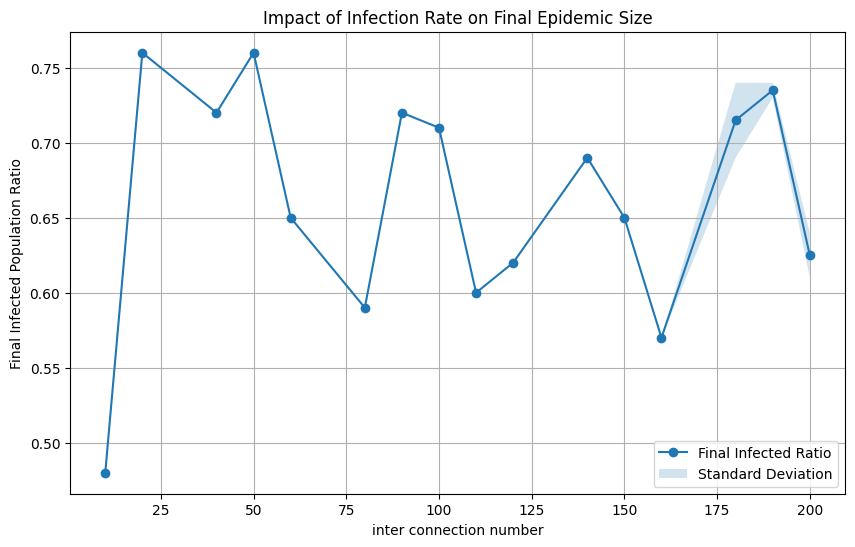

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

def read_and_process_csv(directory):
    """
    讀取指定資料夾內（包含子資料夾）的 CSV 檔案，並對相同感染率的數據取平均與標準差
    """
    # 遞迴搜尋所有 CSV 檔案 (包含子資料夾內的)
    csv_files = glob(os.path.join(directory, "**", "*.csv"), recursive=True)
    if not csv_files:
        print("❌ 未找到任何 CSV 檔案！請確認資料夾路徑是否正確")
        return

    # 儲存所有數據
    grouped_data = {}

    for file in csv_files:
        df = pd.read_csv(file)

        # 取得感染率、恢復率
        connection = df["Inter-cluster Connections"].iloc[0]
        recovery_rate = df["Recovery Rate"].iloc[0]

        # 取得最終感染比例 (最後一個 step 的 Infected Count / Total People)
        final_infected_ratio = df["Infected Count"].iloc[-1] / df["Total People"].iloc[-1]

        # 依據感染率分組
        if connection not in grouped_data:
            grouped_data[connection] = []

        grouped_data[connection].append(final_infected_ratio)

    # 計算平均與標準差
    results = {}
    for connection, data_list in grouped_data.items():
        mean_value = np.mean(data_list)
        std_value = np.std(data_list)
        results[connection] = (mean_value, std_value)

    return results

def plot_results(results):
    """
    繪製最終感染比例與感染率的關係，並標記標準差
    """
    connections = sorted(results.keys())  # 確保 x 軸有序
    mean_values = [results[rate][0] for rate in connections]
    std_values = [results[rate][1] for rate in connections]

    plt.figure(figsize=(10, 6))
    plt.plot(connections, mean_values, marker="o", linestyle="-", label="Final Infected Ratio")
    plt.fill_between(connections,
                     np.array(mean_values) - np.array(std_values),
                     np.array(mean_values) + np.array(std_values),
                     alpha=0.2, label="Standard Deviation")

    plt.xlabel("inter connection number")
    plt.ylabel("Final Infected Population Ratio")
    plt.title("Impact of Infection Rate on Final Epidemic Size")
    plt.legend()
    plt.grid(True)
    plt.show()


# 🏁 讀取 CSV 並繪製圖表
directory = r"C:\Users\ASUS\Documents\GitHub\sis-model\results\classical\diff_connections_ratio_cool_random"  # 📁 你的 CSV 存放目錄
processed_data = read_and_process_csv(directory)
if processed_data:
    plot_results(processed_data)

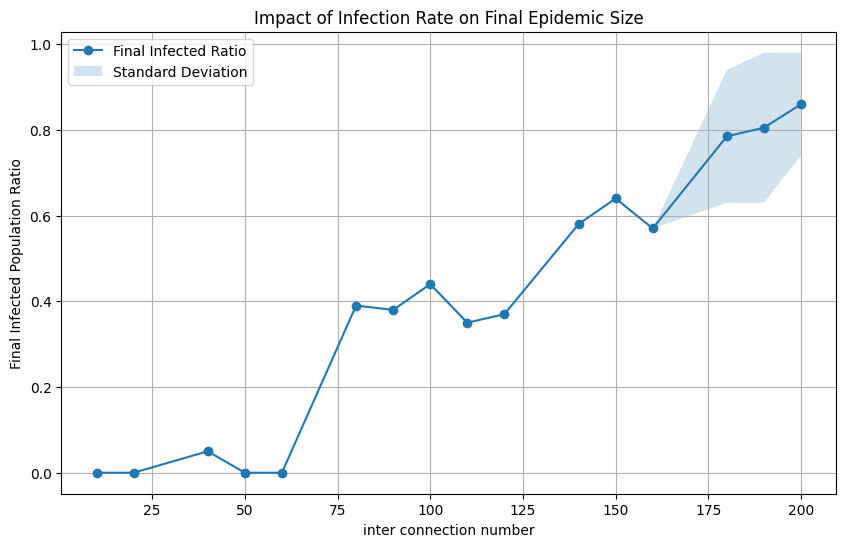

In [2]:
directory = r"C:\Users\ASUS\Documents\GitHub\sis-model\results\quantum\diff_connections_ratio_cool_random"  # 📁 你的 CSV 存放目錄
processed_data = read_and_process_csv(directory)
if processed_data:
    plot_results(processed_data)

In [3]:
import numpy as np
infect_rate = 0.2
infect = (2 / np.pi) * np.arcsin(np.sqrt(infect_rate))
(np.sin(infect * np.pi / 2))**2
print(infect)

0.2951672353008665
